# Lab - EDA Univariate Analysis: Diving into Amazon UK Product Insights
---

**Objective**: Explore the product listing dynamics on Amazon UK to extract actionable business insights. By understanding the distribution, central tendencies, and relationships of various product attributes, businesses can make more informed decisions on product positioning, pricing strategies, and inventory management.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

### Part 1: Understanding Product Categories

**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1. **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?

2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

### Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?

3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 

### Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?


**1. Import dependencies**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**2. Load Dataset**

In [4]:
# Define the relative file
dataset_path = r".\amazon dataset\amz_uk_price_prediction_dataset.csv"  #   'r' prefix ensures the backslashes are treated correctly

# Load the dataset into a pandas DataFrame
data = pd.read_csv(dataset_path)

# Make a copy of DataFrame
df = data.copy()

# Display the first 5 rows of the dataset to verify it loaded correctly
data.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


**3. Dataset Overview**

In [5]:
# Display the DataFrame
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [6]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [7]:
# Create a list of existing column names
cols_list = list(df.columns)

print(cols_list)
new_cols_list = []

for col in cols_list:
    
    # Clean the column name
    cleaned_col = col.strip().lower()
    
    # Rename specific columns
    if cleaned_col == "isbestseller":
        cleaned_col = "bestseller"
    elif cleaned_col == "boughtinlastmonth":
        cleaned_col = "lastmonth"
    
    # Append cleaned name to new list
    new_cols_list.append(cleaned_col)

# Print new column list
print(new_cols_list)

# Assign the cleaned column names back to the DataFrame
df.columns = new_cols_list


['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller', 'boughtInLastMonth', 'category']
['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'bestseller', 'lastmonth', 'category']


In [8]:
df.head()

,uid,asin,title,stars,reviews,price,bestseller,lastmonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [9]:
# Display the shape of the DataFrame
df.shape

(2443651, 9)

In [10]:
# Display columns of the DataFrame
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'bestseller',
       'lastmonth', 'category'],
      dtype='object')

In [11]:
# Display columns datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column      Dtype  
---  ------      -----  
 0   uid         int64  
 1   asin        object 
 2   title       object 
 3   stars       float64
 4   reviews     int64  
 5   price       float64
 6   bestseller  bool   
 7   lastmonth   int64  
 8   category    object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [12]:
# Descriptive statistics
df.describe().T.round(2)        # Round values upto two decimals points

,count,mean,std,min,25%,50%,75%,max
uid,2443651.0,1370545.35,816056.17,1.0,658921.50,1349029.00,2060685.50,2828593.0
stars,2443651.0,2.15,2.19,0.0,0.00,0.00,4.40,5.0
reviews,2443651.0,480.63,5944.12,0.0,0.00,0.00,59.00,1356658.0
price,2443651.0,89.24,345.61,0.0,9.99,19.09,45.99,100000.0
lastmonth,2443651.0,25.90,240.48,0.0,0.00,0.00,0.00,50000.0


In [13]:
# Create a boolean DataFrame indicating missing (NaN/None) values
missing_counts = pd.isnull(df).sum()

# Check the data type of missing_counts (pandas Series, i.e., 1D structure)
print(type(missing_counts))

# Display the number of missing values for each column (1D Series output)
missing_counts


<class 'pandas.core.series.Series'>


uid           0
asin          0
title         0
stars         0
reviews       0
price         0
bestseller    0
lastmonth     0
category      0
dtype: int64

In [14]:
# Sum the missing-value counts across all columns to get a total
total_missing_count = missing_counts.sum()   # returns an integer output

# Print the total number of missing values in the DataFrame
print("Total missing values in DataFrame:", total_missing_count)

Total missing values in DataFrame: 0


**Key obesercations**
- **Total Features:** There are total 9 features in the dataset, out of which 5 features are and rest 4 features are categorical.
- The dataset contains **no missing values**.

---

**Solution 1: Understanding Product Categories**

*Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?*


**1. Frequency Table**
-  Generate a frequency table for the product `category`.
- Which are the top 5 most listed product categories?

In [15]:
df.head()

,uid,asin,title,stars,reviews,price,bestseller,lastmonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [16]:
# Generate a frequency table for product categories
category_frequency_table = df["category"].value_counts(sort= False).reset_index()

print(type(category_frequency_table))

print(category_frequency_table.shape)

# Rename columns for clarity
category_frequency_table.columns = ["category","listing_count"]

# Display the top 5 most frequent categories
category_frequency_table

<class 'pandas.core.frame.DataFrame'>
(296, 2)


,category,listing_count
0,Hi-Fi Speakers,8745
1,"CD, Disc & Tape Players",8798
2,Wearable Technology,8906
3,Light Bulbs,9183
4,Bathroom Lighting,254
...,...,...
291,Media Streaming Devices,9414
292,Hi-Fi Receivers & Separates,9199
293,"GPS, Finders & Accessories",9349
294,Indoor Lighting,8586


In [17]:
# Filter out top-20 categories using sort_values() methods
top_20_categories = category_frequency_table.sort_values(by= "listing_count", ascending= False).head(20)

# top_20_categories = category_frequency_table.sort_values(by= "listing_count", ascending= False)[:20]

# Create additinal rank column
top_20_categories['rank'] = [(x) for x in range(1, len(top_20_categories)+1)]

# Define new column sequence
cols = ["rank"] + [c for c in top_20_categories.columns if c != "rank"]                 # Output: cols = ["rank", "category", "listing_count"]

# Assign new columns back to DataFrame
top_20_categories = top_20_categories[cols]

# Display top-20 categories
top_20_categories.head(20)

,rank,category,listing_count
23,1,Sports & Outdoors,836265
114,2,Beauty,19312
202,3,"Handmade Clothing, Shoes & Accessories",19229
81,4,Bath & Body,19092
69,5,Birthday Gifts,18978
89,6,Manicure & Pedicure Products,18940
48,7,Skin Care,18769
140,8,Make-up,18756
284,9,Hair Care,18735
31,10,Fragrances,18564


In [18]:
# Filter out top-5 categories
top_5_categories = top_20_categories[:5]
# top_5_categories = top_20_categories.head(5)

# Display top-5 categories
top_5_categories.head()


,rank,category,listing_count
23,1,Sports & Outdoors,836265
114,2,Beauty,19312
202,3,"Handmade Clothing, Shoes & Accessories",19229
81,4,Bath & Body,19092
69,5,Birthday Gifts,18978


In [19]:
# Conceptual Understanding: Series vs DataFrame

# Generate frequency counts for each product category
category_frequency = df["category"].value_counts()

# Confirm the data type and shape (1D structure)
print(type(category_frequency))        # pandas Series (1D)
print(category_frequency.shape)        # (number_of_unique_categories,)

# Display first 5 values of the pandas Series
display(category_frequency.head())

print("--------------------------------\n")

# Convert the pandas Series into a DataFrame (2D structure)
category_frequency_table = pd.DataFrame(category_frequency)

# Confirm the data type and shape (2D structure)
print(type(category_frequency_table))  # pandas DataFrame (2D)
print(category_frequency_table.shape)  # (number_of_unique_categories, 1)

# Display the full DataFrame
display(category_frequency_table)

<class 'pandas.core.series.Series'>
(296,)


category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

--------------------------------

<class 'pandas.core.frame.DataFrame'>
(296, 1)


,count
category,
Sports & Outdoors,836265
Beauty,19312
"Handmade Clothing, Shoes & Accessories",19229
Bath & Body,19092
Birthday Gifts,18978
...,...
Motorbike Chassis,107
Alexa Built-In Devices,107
Plugs,107


2. **Visualizations**:

    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

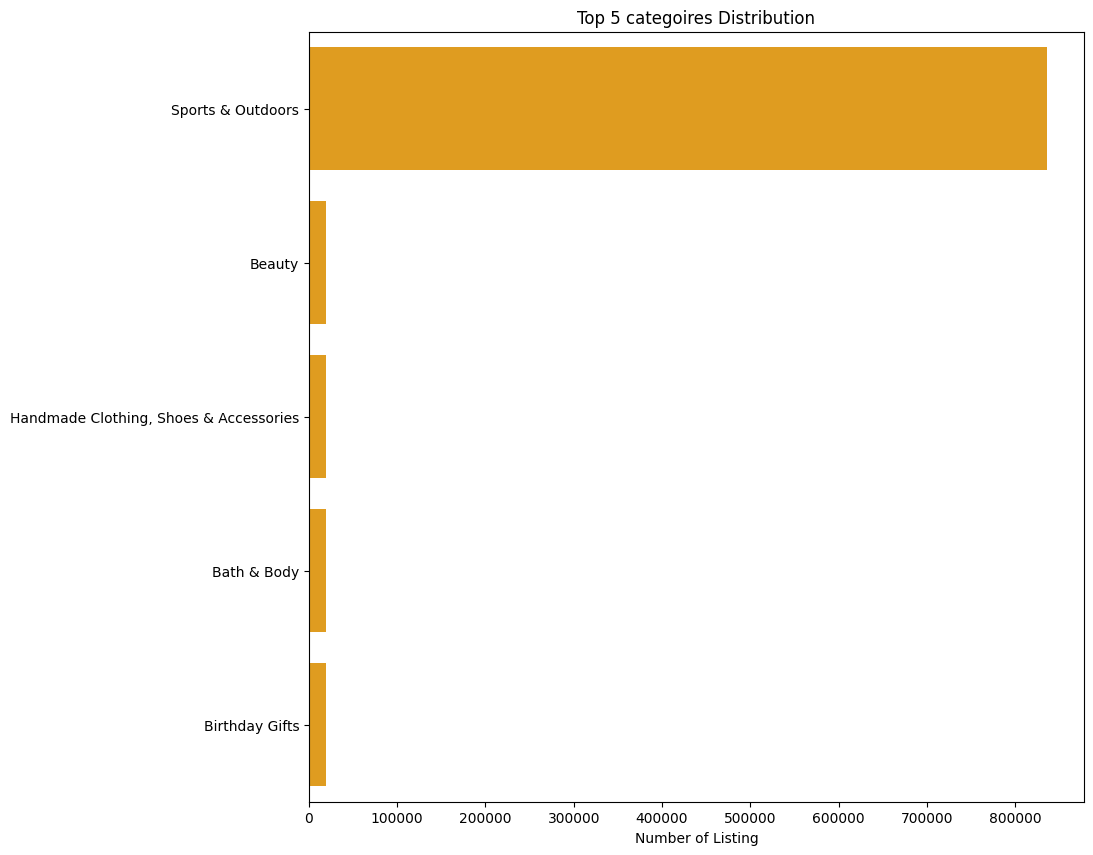

In [20]:
plt.figure(figsize=[10, 10])
sns.barplot( data= top_5_categories, x = "listing_count" , y = "category", color="orange")
plt.title("Top 5 categoires Distribution")
plt.xlabel("Number of Listing")
plt.ylabel("")
# plt.xticks(rotation= 45)
plt.show()

**Key Insights**

- `Sports & Outdoors` category dominated one-sided and has more listings. This means more items related to `Sports & Outdoors` listings are available to sell on website as compared to other categories.

**Problem 2: Delving into Product Pricing**

*Business Question: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?*

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?


3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 

In [21]:
# Measures of Centrality (Mean, Median, Mode)

price_mean = df["price"].mean()
price_median = df["price"].median()
price_mode = df["price"].mode().iloc[0]

print("Mean price:", price_mean)
print("Median price:", price_median)
print("Mode price:", price_mode)

Mean price: 89.24380943923661
Median price: 19.09
Mode price: 9.99


**Key Insight**

The average price is much higher than the most common price. This means that while most products are listed around €9.99, a smaller number of high-priced items significantly increase the average. As a result, the mean does not represent the typical product price as well as the mode (or the median).

In [22]:
# Measure of Dispersion (Variance, Standard Deviation, Range and IQR)

price_max = df["price"].max()
price_min = df["price"].min()

price_var = df["price"].var()
price_std = df["price"].std()

# Range
price_range = price_max - price_min

# Interquartile Range (IQR)
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
price_iqr = Q3 - Q1

# Print results
print(f"Variance: {price_var:.2f}")
print(f"Standard Deviation: {price_std:.2f}")
print(f"Range: {price_range:.2f}")
print(f"IQR: {price_iqr:.2f}")


Variance: 119445.49
Standard Deviation: 345.61
Range: 100000.00
IQR: 36.00


**key Insight**

- Variance (119,445.49) and standard deviation (345.61) are high, which means product prices differ a lot from each other.
- Range (100,000) shows a very big gap between the cheapest and the most expensive product.
- IQR (36.00) means that the middle 50% of products are priced within a $36 range.

In [23]:
# Quick summary of descriptive statistics for the 'price' column
# Includes count, mean, standard deviation, min, quartiles, and max

df["price"].describe().round(2)

count    2443651.00
mean          89.24
std          345.61
min            0.00
25%            9.99
50%           19.09
75%           45.99
max       100000.00
Name: price, dtype: float64

***Key Observations***
- The **average product** price is **$89.24**, but this value is heavily influenced by very high-priced items.

- The **median price** is **$19.09**, which indicates that most products are priced well below the mean.

- The **standard deviation (345.61)** is very large relative to the mean, suggesting high price variability.

- **75% of products are priced below $45.99**, showing that the majority of listings are in the low-to-mid price range.

- The **maximum price of $100,000** is extremely high compared to the rest of the distribution and likely represents **outliers or special listings**.

- The **minimum price of $0.00** may indicate:
    - Free items
    - Missing or incorrectly recorded prices

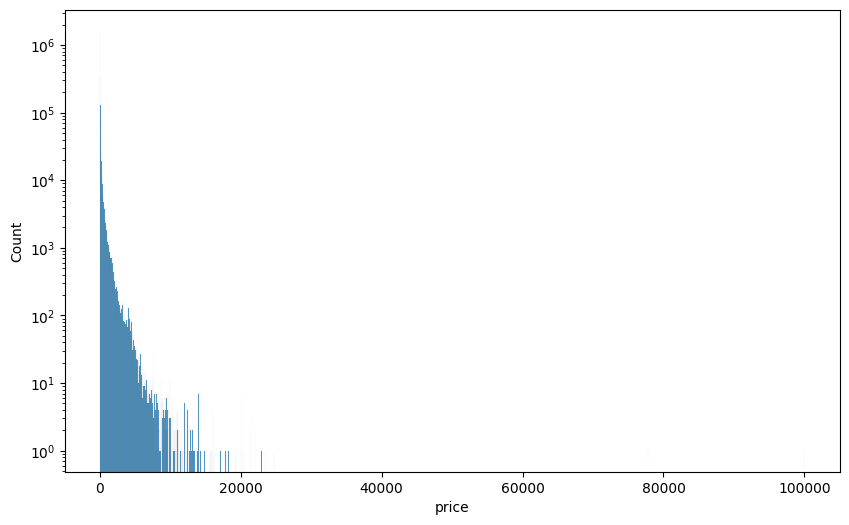

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df.price, bins='auto')
plt.yscale("log")
plt.show()

**Note**

- The above histogram is difficult to read because the price data is **highly skewed**. Most products have **low prices**, while a small number of **very expensive products** stretch the x-axis and compress the bars for cheaper items. This makes the main distribution hard to see.


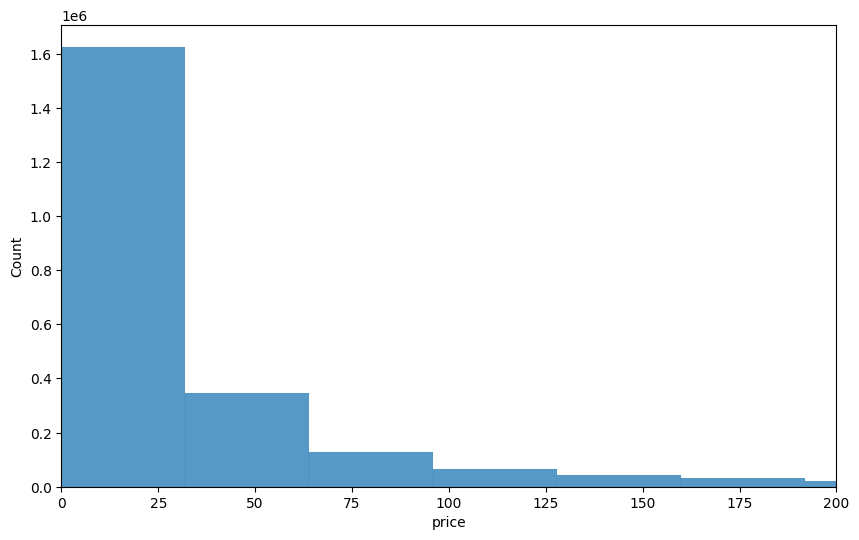

In [25]:
# Limit Price range and improve readabillity

plt.figure(figsize=(10, 6))
sns.histplot(df.price, bins='auto')
plt.xlim(0, 200)                        # Price range where products falls
plt.show()

**Insights**

- Most products fall roughly in the €0–€50 range.
- As price increases, the number of products drops sharply.
- Very expensive products are rare, but they still extend the price range significantly.

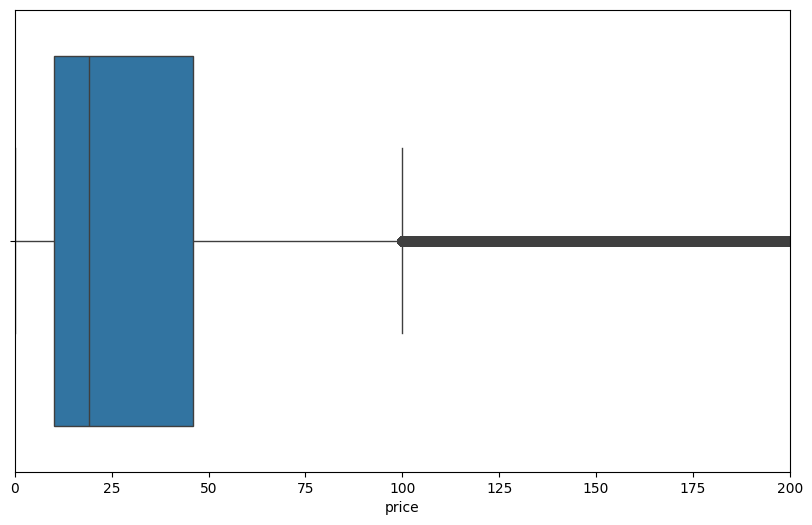

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="price")
plt.xlim(0, 200)
plt.show()

**Insights**
- The box is concentrated at low prices, showing that most products are inexpensive.
- The median is low, confirming that typical prices are cheap.
- There are many points far to the right, which are high-price outliers.
- This clearly indicates a strong right skew in product prices.

### Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

In [27]:
df.head()

,uid,asin,title,stars,reviews,price,bestseller,lastmonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [28]:
# Measures of Centrality for product ratings

stars_mean = df["stars"].mean()
stars_median = df["stars"].median()
stars_mode = df["stars"].mode().iloc[0]

print(f"Mean rating: {stars_mean:.2f}")
print(f"Median rating: {stars_median}")
print("Mode rating:")
print(stars_mode)

Mean rating: 2.15
Median rating: 0.0
Mode rating:
0.0


In [40]:
stars_0_percent = df[df['stars']==0]['stars'].value_counts()/ df.shape[0] *100

round(stars_0_percent, 2)

stars
0.0    50.16
Name: count, dtype: float64

**Insights**

- 50 % of the products have a rating of 0, which indicates no customer ratings yet, means no concrete conclusion about product quality.

- Because many products are unrated, the median and mode are 0.

- The mean is pulled up to 2.15 by products that do have ratings.

# 

In [41]:
# Measures of Dispersion for product ratings

stars_var = df["stars"].var()
stars_std = df["stars"].std()

# Interquartile Range (IQR)
Q1 = df["stars"].quantile(0.25)
Q3 = df["stars"].quantile(0.75)
stars_iqr = Q3 - Q1

print(f"Variance: {stars_var:.2f}")
print(f"Standard Deviation: {stars_std:.2f}")
print(f"IQR: {stars_iqr:.2f}")

Variance: 4.82
Standard Deviation: 2.19
IQR: 4.40


In [44]:
df['stars'].describe().round(2)

count    2443651.00
mean           2.15
std            2.19
min            0.00
25%            0.00
50%            0.00
75%            4.40
max            5.00
Name: stars, dtype: float64

**Insight**

- Customer ratings are not evenly distributed across products. A small number of rated products receive most of the feedback, while many products have no ratings at all, which increases apparent variability.

In [ ]:
# 
rated_df = df[df['stars']>0]

rated_df['stars'].describe().round(2)

count    1218010.00
mean           4.32
std            0.56
min            1.00
25%            4.10
50%            4.40
75%            4.60
max            5.00
Name: stars, dtype: float64

3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

In [47]:
# Calculate skewness and kurtosis for ratings

skewness_score = df["stars"].skew()
kurtosis_score = df["stars"].kurtosis()

print(f"Skewness score for stars column: {skewness_score:.2f}")
print(f"Kurtosis score for stars column: {kurtosis_score:.2f}")

Skewness score for stars column: 0.08
Kurtosis score for stars column: -1.93


In [48]:
# Calculate skewness and kurtosis score without 0 star ratings

skewness_score_without_0 = rated_df["stars"].skew()
kurtosis_score_without_0 = rated_df["stars"].kurtosis()

print(f"Skewness score for stars column: {skewness_score_without_0:.2f}")
print(f"Kurtosis score for stars column: {kurtosis_score_without_0:.2f}")

Skewness score for stars column: -2.38
Kurtosis score for stars column: 9.78


**Skewness = 0:**

- The distribution is perfectly symmetrical, resembling a normal distribution.

**Skewness > 0:**

- The distribution is positively skewed (right-skewed).
- Longer tail on the right side.
- The bulk of the data is concentrated on the left.

**Skewness < 0:**

- The distribution is negatively skewed (left-skewed).
- Longer tail on the left side.
- The bulk of the data is concentrated on the right.

**Insights from Skewness and Kurtosis Analysis (Product Ratings)**

***Including 0-star (unrated) products***

- **Skewness ≈ 0** indicates an almost **symmetric distribution**.
- **Low (negative) kurtosis** suggests a **flat distribution** with ratings spread out.
- This symmetry is **misleading** and mainly caused by a large number of **unrated (0-star) products**.

***Excluding 0-star products (only rated items)***

- **Strong negative skewness** shows that most ratings are **high (4–5 stars)**.
- **High kurtosis** indicates ratings are **highly concentrated** with strong peaks.
- Customer feedback is **not evenly distributed** but clustered toward positive ratings.

***Business Insight***

- Many Amazon UK products are **unrated**, which distorts overall rating statistics.
- When ratings exist, customers tend to give **consistently high scores**.
- For accurate customer sentiment analysis, **exclude 0-star products**.

**Visualizations:**

Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

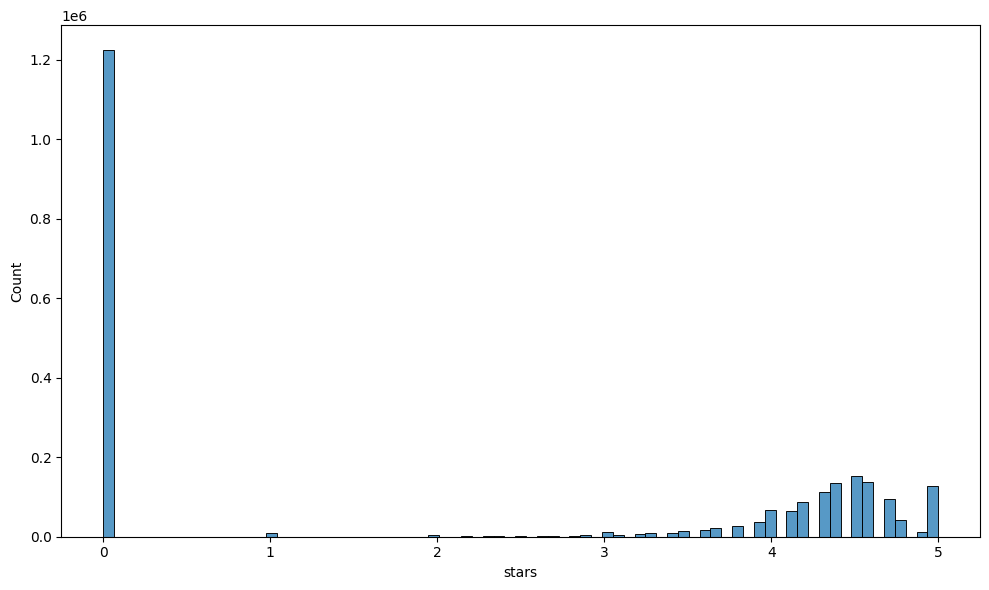

In [ ]:
# Visualization inclusing 0 Star ratings
plt.figure(figsize= [10, 6])

sns.histplot(data= df, x= 'stars', bins= 'auto')
plt.tight_layout()
plt.show()

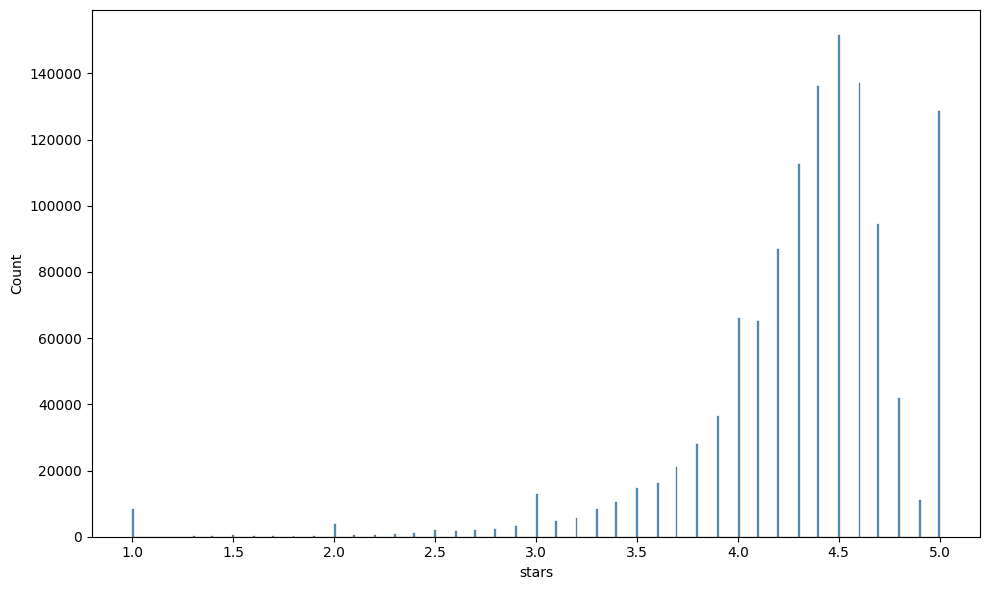

In [52]:
# Visualization excluding 0 Star ratings
plt.figure(figsize= [10, 6])

sns.histplot(data= rated_df, x= 'stars', bins= 'auto')
plt.tight_layout()
plt.show()

**Note**
- Since product ratings are **discrete values** rather than **continuous values**, the histogram shows **narrow bars with gaps between them**. This happens because ratings occur only at specific points (e.g., 1, 2, 3, 4, 5) instead of across a continuous range, which is not typically seen in histograms of continuous data.

**Insights**

- When all products are included, the most common value is 0 stars. This indicates that many products are unrated, not poorly rated.

- When 0-star products are excluded, the distribution clearly peaks between 4 and 5 stars.

    - 4.5 stars (around 4–4.7) appears to be the most frequent rating.

    - Very few products receive low ratings (1–2 stars).
    